# Power Analysis - sample size & MDE for A/B tests
Requirements: numpy, pandas, matplotlib, statsmodels


In [1]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
import math

In [2]:
np.random.seed(42)

In [3]:
# -----------------------------
# Helper: metrics & formatting
# -----------------------------
def pct(x): return f"{100*x:.2f}%"
def pp(x): return f"{100*x:.2f} pp"

In [4]:
# -----------------------------
# 1) Required sample size per group
# -----------------------------
def required_n_per_group(p0, uplift_pp=None, uplift_rel=None, alpha=0.05, power=0.8, ratio=1.0):
    '''
    p0: baseline conversion (0-1)
    uplift_pp: absolute uplift in proportion points (e.g., 0.0068 for 0.68 pp). If provided, used.
    uplift_rel: relative uplift (e.g., 0.1323 for +13.23%). If provided and uplift_pp is None, used to compute p1.
    alpha: significance level
    power: desired power (1 - beta)
    ratio: n1 / n0 (treatment / control)
    Returns: required n_control, n_treatment
    '''
    if uplift_pp is not None:
        p1 = p0 + uplift_pp
    elif uplift_rel is not None:
        p1 = p0 * (1 + uplift_rel)
    else:
        raise ValueError('Provide uplift_pp or uplift_rel')
    # guard: probabilities in (0,1)
    p1 = max(min(p1, 0.9999), 1e-6)

    # Cohen's h effect size for proportions
    effect = proportion_effectsize(p1, p0)
    analysis = NormalIndPower()
    n0 = analysis.solve_power(effect_size=effect, power=power, alpha=alpha, ratio=ratio, alternative='two-sided')
    n1 = math.ceil(n0 * ratio)
    return math.ceil(n0), n1, p1, effect

# -----------------------------
# 2) Minimum Detectable Effect (MDE) given sample sizes
# -----------------------------
def mde_from_n(p0, n_per_group, alpha=0.05, power=0.8, ratio=1.0):
    '''
    Returns absolute uplift (p1 - p0) detectable with given n per group.
    '''
    analysis = NormalIndPower()
    # search effect size that yields required sample size
    # use binary search on effect size
    low, high = 1e-6, 2.0
    for _ in range(40):
        mid = (low + high) / 2
        try:
            n_est = analysis.solve_power(effect_size=mid, power=power, alpha=alpha, ratio=ratio, alternative='two-sided')
        except Exception:
            n_est = float('inf')
        if n_est > n_per_group:
            low = mid
        else:
            high = mid
    h = high
    # convert h back to p1: h = 2 * (arcsin(sqrt(p1)) - arcsin(sqrt(p0)))
    # => arcsin(sqrt(p1)) = arcsin(sqrt(p0)) + h/2
    a0 = math.asin(math.sqrt(p0))
    a1 = a0 + h / 2
    p1 = math.sin(a1)**2
    return p1 - p0, p1, h


Observed:
  Baseline (p0) = 5.14%
  Observed treatment (p1) = 5.82%
  Observed absolute uplift = 0.68 pp (13.23% relative)\n
Sample size to reliably detect the observed uplift (80% power, alpha=0.05):
  required n per group ≈ 17568  (treatment 17568)
  effect size (Cohen h) = 0.0299\n
Given n = 5000 per group:
  Minimum detectable absolute uplift (80% power) = 1.31 pp
  Which corresponds to p1 ≈ 6.45% (Cohen h = 0.0560)\n
Power to detect the observed uplift (0.68 pp) with n=5000 per group: 0.321\n


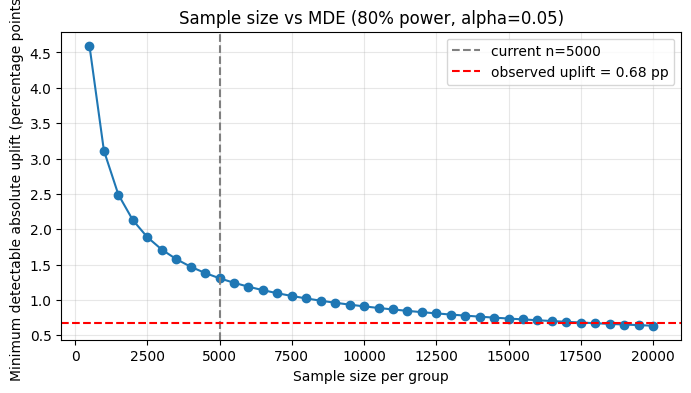

In [5]:
# -----------------------------
# 3) Demo using A/B numbers
# -----------------------------
def main():
    # Observed baseline and uplift from A/B experiment
    p0 = 0.0514   # control CR
    p1_obs = 0.0582
    abs_uplift_obs = p1_obs - p0

    print('Observed:')
    print(f'  Baseline (p0) = {pct(p0)}')
    print(f'  Observed treatment (p1) = {pct(p1_obs)}')
    print(f'  Observed absolute uplift = {pp(abs_uplift_obs)} ({(abs_uplift_obs/p0)*100:.2f}% relative)\\n')

    # 1) Required sample size per group to detect the observed uplift (at 80% power, alpha=0.05)
    n0, n1, p1_target, effect = required_n_per_group(p0, uplift_pp=abs_uplift_obs, alpha=0.05, power=0.8, ratio=1.0)
    print('Sample size to reliably detect the observed uplift (80% power, alpha=0.05):')
    print(f'  required n per group ≈ {n0}  (treatment {n1})')
    print(f'  effect size (Cohen h) = {effect:.4f}\\n')

    # 2) Given our experiment used n=5000 per group, compute MDE
    n_obs = 5000
    mde_pp, mde_p1, h = mde_from_n(p0, n_obs, alpha=0.05, power=0.8, ratio=1.0)
    print(f'Given n = {n_obs} per group:')
    print(f'  Minimum detectable absolute uplift (80% power) = {pp(mde_pp)}')
    print(f'  Which corresponds to p1 ≈ {pct(mde_p1)} (Cohen h = {h:.4f})\\n')

    # 3) Power for observed uplift with current n
    analysis = NormalIndPower()
    effect_obs = proportion_effectsize(p1_obs, p0)
    power_obs = analysis.solve_power(effect_size=effect_obs, nobs1=n_obs, alpha=0.05, ratio=1.0, alternative='two-sided')
    print(f'Power to detect the observed uplift ({pp(abs_uplift_obs)}) with n={n_obs} per group: {power_obs:.3f}\\n')

    # 4) Simple plot: sample size vs detectable absolute uplift
    ns = np.arange(500, 20001, 500)
    mdes = []
    for n in ns:
        mde, _, _ = mde_from_n(p0, n, alpha=0.05, power=0.8)
        mdes.append(mde)
    plt.figure(figsize=(8,4))
    plt.plot(ns, np.array(mdes)*100, marker='o')
    plt.axvline(n_obs, color='gray', linestyle='--', label=f'current n={n_obs}')
    plt.axhline(abs_uplift_obs*100, color='red', linestyle='--', label=f'observed uplift = {abs_uplift_obs*100:.2f} pp')
    plt.xlabel('Sample size per group')
    plt.ylabel('Minimum detectable absolute uplift (percentage points)')
    plt.title('Sample size vs MDE (80% power, alpha=0.05)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    return {
        'required_n_for_observed_uplift': (n0, n1),
        'mde_at_n_obs': (mde_pp, mde_p1),
        'power_for_observed_uplift': power_obs
    }

if __name__ == '__main__':
    results = main()

Although we observed a positive uplift of 0.68 percentage points, our power analysis shows that detecting such a small effect reliably would require approximately 17,568 users per group.

Our experiment only included 5,000 users per group. With this sample size, the minimum detectable effect at 80% power is 1.31 percentage points — nearly double the observed uplift.

Furthermore, the statistical power to detect a 0.68pp improvement with 5,000 users per group is only 32%. This means that even if the treatment truly improves conversion by 0.68pp, the experiment would fail to detect it roughly two-thirds of the time.

Therefore, the lack of statistical significance in the earlier test is likely due to insufficient sample size rather than the absence of a real effect.

This illustrates a critical principle in experimentation: failing to reject the null hypothesis does not imply no effect — it may indicate an underpowered study.

Designing experiments properly before launching them is often more important than analyzing them afterward.

#### Rerunning A/B Test

In [6]:
import numpy as np
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency, norm
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
import math

# ---------- helpers ----------
def required_n_per_group(p0, uplift_pp=None, uplift_rel=None, alpha=0.05, power=0.8, ratio=1.0):
    if uplift_pp is not None:
        p1 = p0 + uplift_pp
    elif uplift_rel is not None:
        p1 = p0 * (1 + uplift_rel)
    else:
        raise ValueError('Provide uplift_pp or uplift_rel')
    p1 = max(min(p1, 0.9999), 1e-6)
    effect = proportion_effectsize(p1, p0)
    analysis = NormalIndPower()
    n0 = analysis.solve_power(effect_size=effect, power=power, alpha=alpha, ratio=ratio, alternative='two-sided')
    return math.ceil(n0), math.ceil(n0*ratio), p1, effect

def proportion_ci(count, n, alpha=0.05):
    p = count / n
    z = norm.ppf(1 - alpha/2)
    se = math.sqrt(p*(1-p)/n)
    lower = p - z*se
    upper = p + z*se
    return max(0, lower), min(1, upper), se

def diff_prop_ci(p0, n0, p1, n1, alpha=0.05):
    diff = p1 - p0
    z = norm.ppf(1 - alpha/2)
    se = math.sqrt(p0*(1-p0)/n0 + p1*(1-p1)/n1)
    lower = diff - z*se
    upper = diff + z*se
    return diff, lower, upper, se

# ---------- simulation & test ----------
def simulate_ab(n_control, n_treatment, p_control, p_treatment, seed=42):
    rng = np.random.default_rng(seed)
    control = rng.binomial(1, p_control, n_control)
    treatment = rng.binomial(1, p_treatment, n_treatment)
    df = pd.DataFrame({
        'group': ['control']*n_control + ['treatment']*n_treatment,
        'converted': np.concatenate([control, treatment])
    })
    return df

def summarize(df):
    summary = df.groupby('group')['converted'].agg(['sum','count']).reset_index()
    summary['cr'] = summary['sum'] / summary['count']
    return summary

def two_prop_test(summary):
    count = summary['sum'].values
    nobs = summary['count'].values
    stat, pval = proportions_ztest(count, nobs, alternative='two-sided')
    return stat, pval

def chi2_test(df):
    table = pd.crosstab(df['group'], df['converted'])
    chi2, p, dof, expected = chi2_contingency(table)
    return chi2, p, table, expected

# ---------- main routine ----------
def rerun_ab_with_recommended_size(
        p0=0.0514,
        abs_uplift=0.0068,
        alpha=0.05,
        power=0.8,
        seed=2026):
    print('Parameters:')
    print(f'  baseline p0 = {p0:.4f} ({100*p0:.2f}%)')
    print(f'  target absolute uplift = {abs_uplift:.4f} ({100*abs_uplift:.2f} pp)')
    # recompute recommended n
    n0, n1, p1_target, effect = required_n_per_group(p0, uplift_pp=abs_uplift, alpha=alpha, power=power, ratio=1.0)
    print('\nRecommended sample size (recomputed):')
    print(f'  required n per group ≈ {n0} (treatment {n1})')
    print(f'  target treatment rate p1_target = {p1_target:.4f} ({100*p1_target:.2f}%)')
    print(f'  Cohen h effect size = {effect:.4f}\n')

    # simulate using recommended n
    n_sim = n0
    p_treatment = p0 + abs_uplift
    print(f'Running one simulated experiment with n={n_sim} per group (seed={seed}) ...\n')
    df = simulate_ab(n_sim, n_sim, p0, p_treatment, seed=seed)
    summary = summarize(df)
    print('Summary:')
    print(summary[['group','sum','count','cr']].to_string(index=False))

    # tests
    z_stat, z_p = two_prop_test(summary)
    chi2, chi_p, table, expected = chi2_test(df)
    print(f'\nTwo-proportion z-test: stat={z_stat:.3f}, p-value={z_p:.4f}')
    print(f'Chi-square test: chi2={chi2:.3f}, p-value={chi_p:.4f}')

    # CIs and uplift
    row0 = summary.iloc[0]
    row1 = summary.iloc[1]
    lo0, up0, se0 = proportion_ci(row0['sum'], row0['count'])
    lo1, up1, se1 = proportion_ci(row1['sum'], row1['count'])
    diff, diff_lo, diff_up, diff_se = diff_prop_ci(row0['cr'], row0['count'], row1['cr'], row1['count'])
    abs_uplift_obs = row1['cr'] - row0['cr']
    rel_uplift_obs = (abs_uplift_obs / row0['cr']) if row0['cr'] != 0 else float('inf')

    print('\n95% CIs:')
    print(f'  control: {row0.cr:.4%} (95% CI: {lo0:.4%} — {up0:.4%})')
    print(f'  treatment: {row1.cr:.4%} (95% CI: {lo1:.4%} — {up1:.4%})')
    print(f'\nObserved difference (treatment - control) = {abs_uplift_obs:.4%}')
    print(f'95% CI for difference: [{diff_lo:.4%}, {diff_up:.4%}]')
    print(f'Absolute uplift observed = {100*abs_uplift_obs:.2f} pp  — Relative uplift = {100*rel_uplift_obs:.2f}%')

    # interpretation
    print('\nInterpretation:')
    if z_p < alpha:
        print(f'  The difference is statistically significant (z p={z_p:.4f}). Treatment changed conversion rate.')
    else:
        print(f'  No statistically significant difference (z p={z_p:.4f}).')
        print('  Note: even though we designed for 80% power, a single simulated draw can still fail to detect the effect by chance.')
    return {
        'summary': summary,
        'z_test': (z_stat, z_p),
        'chi2_test': (chi2, chi_p),
        'diff_ci': (diff, diff_lo, diff_up),
        'n_per_group': n_sim
    }

# Run it
if __name__ == '__main__':
    results = rerun_ab_with_recommended_size()

Parameters:
  baseline p0 = 0.0514 (5.14%)
  target absolute uplift = 0.0068 (0.68 pp)

Recommended sample size (recomputed):
  required n per group ≈ 17568 (treatment 17568)
  target treatment rate p1_target = 0.0582 (5.82%)
  Cohen h effect size = 0.0299

Running one simulated experiment with n=17568 per group (seed=2026) ...

Summary:
    group  sum  count       cr
  control  944  17568 0.053734
treatment  975  17568 0.055499

Two-proportion z-test: stat=-0.728, p-value=0.4667
Chi-square test: chi2=0.496, p-value=0.4812

95% CIs:
  control: 5.3734% (95% CI: 5.0400% — 5.7068%)
  treatment: 5.5499% (95% CI: 5.2113% — 5.8884%)

Observed difference (treatment - control) = 0.1765%
95% CI for difference: [-0.2987%, 0.6516%]
Absolute uplift observed = 0.18 pp  — Relative uplift = 3.28%

Interpretation:
  No statistically significant difference (z p=0.4667).
  Note: even though we designed for 80% power, a single simulated draw can still fail to detect the effect by chance.
